In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)
print('Successfully Loaded!')
df = pd.read_csv("creditcard.csv")
df.head(100)

Successfully Loaded!


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,64.0,-0.658305,0.406791,2.037461,-0.291298,0.147910,-0.350857,0.945373,-0.172560,0.025133,-0.778135,-0.196290,0.632955,0.374025,-0.531597,-0.615063,-0.518078,0.003881,-1.288954,-0.797804,0.064133,-0.156096,-0.238805,0.089877,0.421195,-0.352487,0.074783,-0.094192,-0.092493,54.99,0
96,64.0,0.959602,0.370711,0.888613,2.343244,0.352491,1.365515,-0.277771,0.516053,-0.700929,0.468216,0.745612,0.373531,-0.223918,0.417438,1.678400,-0.515702,0.662479,-2.514235,-2.589688,-0.298405,-0.155547,-0.403239,0.356504,-0.696881,-0.198718,-0.220268,0.068546,0.020797,7.55,0
97,67.0,-0.653445,0.160225,1.592256,1.296832,0.997175,-0.343000,0.469937,-0.132470,-0.197794,-0.105006,-0.543662,0.302233,0.141211,-0.207880,0.024108,-1.206877,0.394836,-0.750956,0.440558,0.225920,0.038363,0.336449,-0.014883,0.102959,-0.265322,-0.348637,0.011238,-0.049478,19.85,0
98,67.0,-1.494668,0.837241,2.628211,3.145414,-0.609098,0.258495,-0.012189,0.102136,-0.286164,1.198556,-0.550296,-0.106846,0.208014,-0.680510,0.507764,-0.260264,0.246631,0.008856,0.899416,-0.028352,-0.140047,0.355044,0.332720,0.718193,-0.219366,0.118927,-0.317486,-0.340783,28.28,0


In [10]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, precision_recall_curve
)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')
print('All ML libraries loaded successfully.')

All ML libraries loaded successfully.


# Challenge 2: Transaction Risk Scoring
## Phase 1 — Business Understanding

Credit card companies must identify fraudulent transactions so that customers are not charged for
purchases they did not make. Customers expect safety measures that block fraudulent transactions
before they are processed. The company's goal is to build user confidence by blocking fraud —
ultimately boosting long-term trust and customer retention.

---

### Why Standard Accuracy Fails Here

With only **0.172%** of transactions being fraud, a model that predicts "not fraud" for every
single transaction achieves **99.83% accuracy** — while catching **zero fraudsters**.

For fraud detection we care about:
- **Recall (Sensitivity):** Of all actual fraud cases, what fraction did we catch?
- **Precision:** Of all transactions we flagged as fraud, what fraction actually were fraud?
- **F1-Score:** Harmonic mean of precision and recall — our primary single-number metric.
- **PR-AUC:** Precision-Recall AUC — more informative than ROC-AUC for imbalanced data.

A **false negative** (missed fraud) costs the company real money.  
A **false positive** (wrongly blocked legitimate transaction) costs customer trust.  
The model outputs a probability — the threshold is a **business policy decision**.

## Phase 2 — Data Understanding

### Dataset Column Reference

| Column | Description |
|--------|-------------|
| `V1`–`V28` | PCA principal components. V1 captures the most variance, V28 the least. Values are scaled, centered, and have **no physical meaning** — abstract coordinates in n-dimensional space. Already normalized, do not re-scale. |
| `Time` | Seconds elapsed between each transaction and the **first transaction** in the dataset. Not a real clock time — just relative ordering. |
| `Amount` | Raw transaction dollar amount (not PCA-transformed). Right-skewed — needs log transform. |
| `Class` | Response variable — **1 = fraud**, 0 = legitimate. |

> **Note on PCA ordering:** V1 captures the most variance from the original transaction data,
> V2 the second most, and so on. The original features (merchant, location, card details)
> were anonymized for privacy. Values hover around zero and have no physical units.

In [11]:
fraud_count = df['Class'].sum()
legit_count = len(df) - fraud_count
fraud_pct   = fraud_count / len(df) * 100

print('=' * 55)
print(f'  Total transactions:  {len(df):,}')
print(f'  Features:            {df.shape[1] - 1}')
print(f'  Missing values:      {df.isnull().sum().sum()}')
print('=' * 55)
print(f'\nClass Distribution:')
print(f'  Legitimate (0): {legit_count:>7,}  ({100 - fraud_pct:.2f}%)')
print(f'  Fraud      (1): {fraud_count:>7,}  ({fraud_pct:.4f}%)')
print(f'\n  Imbalance ratio: {legit_count // fraud_count}:1  (legit:fraud)')
print(f"\nNaive baseline accuracy (always predict 'not fraud'): {legit_count / len(df):.4f}")
print('This is why accuracy alone is a USELESS metric for fraud detection.')

  Total transactions:  284,807
  Features:            30
  Missing values:      0

Class Distribution:
  Legitimate (0): 284,315  (99.83%)
  Fraud      (1):     492  (0.1727%)

  Imbalance ratio: 577:1  (legit:fraud)

Naive baseline accuracy (always predict 'not fraud'): 0.9983
This is why accuracy alone is a USELESS metric for fraud detection.


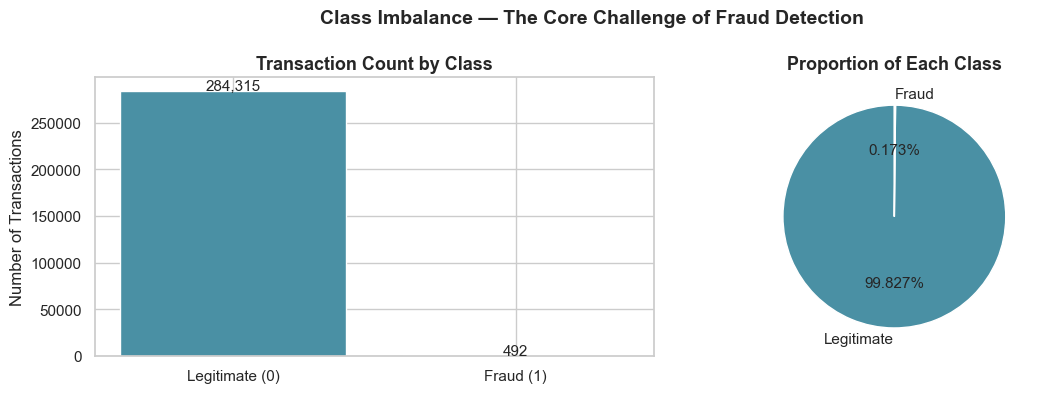

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

class_counts = df['Class'].value_counts()
colors = ['#4a90a4', '#e05c5c']

axes[0].bar(['Legitimate (0)', 'Fraud (1)'], class_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Transaction Count by Class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=11)

axes[1].pie(class_counts.values, labels=['Legitimate', 'Fraud'],
            autopct='%1.3f%%', colors=colors, startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Proportion of Each Class', fontsize=13, fontweight='bold')

plt.suptitle('Class Imbalance — The Core Challenge of Fraud Detection',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

print('Amount statistics by class:')
print(f'\n  Legitimate transactions:')
print(f"    Mean:   ${legit['Amount'].mean():.2f}")
print(f"    Median: ${legit['Amount'].median():.2f}")
print(f"    Max:    ${legit['Amount'].max():,.2f}")
print(f'\n  Fraudulent transactions:')
print(f"    Mean:   ${fraud['Amount'].mean():.2f}")
print(f"    Median: ${fraud['Amount'].median():.2f}")
print(f"    Max:    ${fraud['Amount'].max():,.2f}")
print(f"\nTime range:")
print(f"  Dataset spans {df['Time'].max() / 3600:.1f} hours of transactions")

Amount statistics by class:

  Legitimate transactions:
    Mean:   $88.29
    Median: $22.00
    Max:    $25,691.16

  Fraudulent transactions:
    Mean:   $122.21
    Median: $9.25
    Max:    $2,125.87

Time range:
  Dataset spans 48.0 hours of transactions


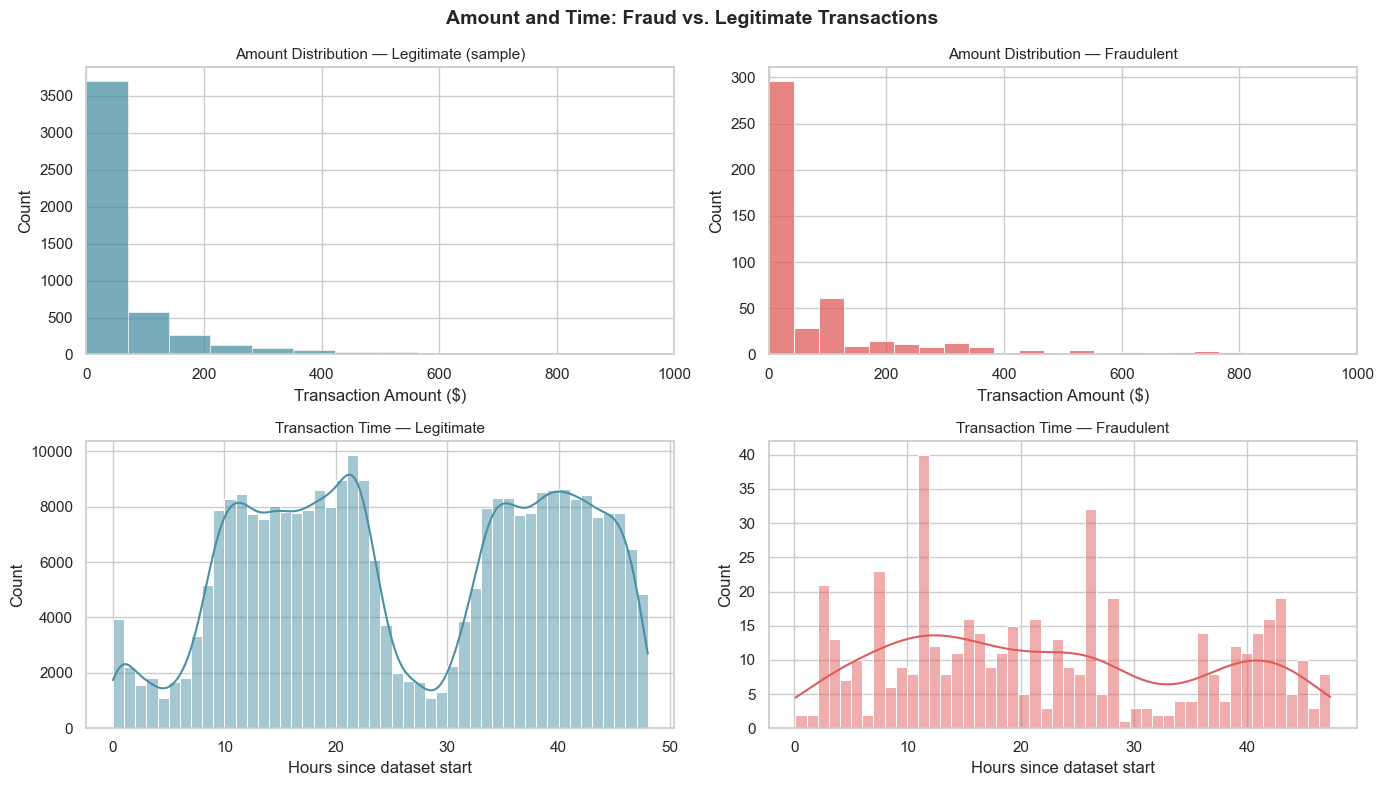

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

legit_sample = legit['Amount'].sample(5000, random_state=42)

sns.histplot(legit_sample, bins=80, ax=axes[0, 0], color='#4a90a4', kde=False)
axes[0, 0].set_title('Amount Distribution — Legitimate (sample)', fontsize=11)
axes[0, 0].set_xlabel('Transaction Amount ($)')
axes[0, 0].set_xlim(0, 1000)

sns.histplot(fraud['Amount'], bins=50, ax=axes[0, 1], color='#e05c5c', kde=False)
axes[0, 1].set_title('Amount Distribution — Fraudulent', fontsize=11)
axes[0, 1].set_xlabel('Transaction Amount ($)')
axes[0, 1].set_xlim(0, 1000)

sns.histplot(legit['Time'] / 3600, bins=48, ax=axes[1, 0], color='#4a90a4', kde=True)
axes[1, 0].set_title('Transaction Time — Legitimate', fontsize=11)
axes[1, 0].set_xlabel('Hours since dataset start')

sns.histplot(fraud['Time'] / 3600, bins=48, ax=axes[1, 1], color='#e05c5c', kde=True)
axes[1, 1].set_title('Transaction Time — Fraudulent', fontsize=11)
axes[1, 1].set_xlabel('Hours since dataset start')

plt.suptitle('Amount and Time: Fraud vs. Legitimate Transactions',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

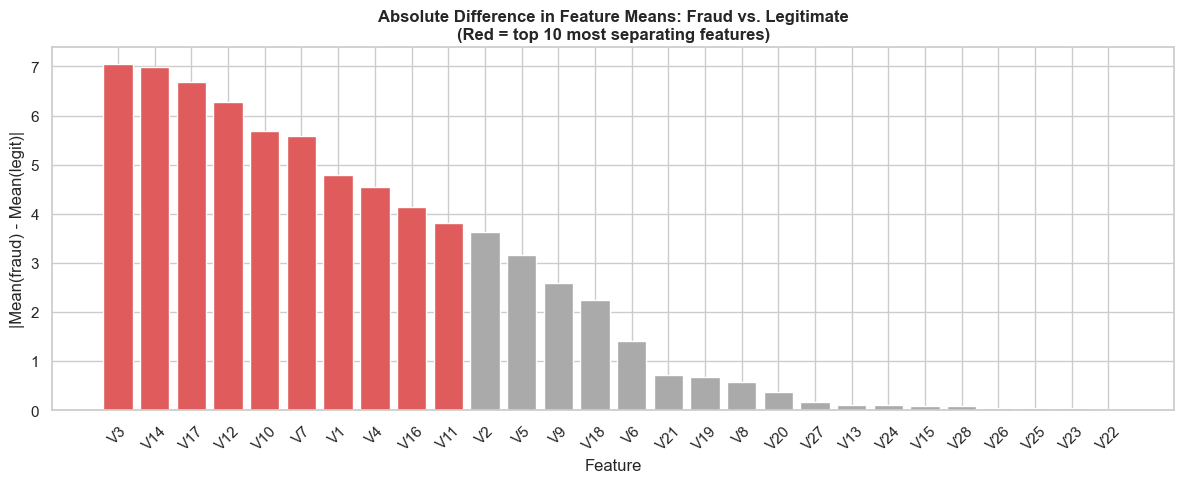

Top 10 most separating features:
  V3: 7.0455
  V14: 6.9838
  V17: 6.6774
  V12: 6.2702
  V10: 5.6867
  V7: 5.5784
  V1: 4.7802
  V4: 4.5499
  V16: 4.1471
  V11: 3.8067


In [15]:
v_features = [f'V{i}' for i in range(1, 29)]

fraud_means = fraud[v_features].mean()
legit_means = legit[v_features].mean()
mean_diff   = (fraud_means - legit_means).abs().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
colors_bar = ['#e05c5c' if v in mean_diff.head(10).index else '#aaa' for v in mean_diff.index]
plt.bar(mean_diff.index, mean_diff.values, color=colors_bar)
plt.title('Absolute Difference in Feature Means: Fraud vs. Legitimate\n'
          '(Red = top 10 most separating features)',
          fontsize=12, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('|Mean(fraud) - Mean(legit)|')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Top 10 most separating features:')
for feat, val in mean_diff.head(10).items():
    print(f'  {feat}: {val:.4f}')

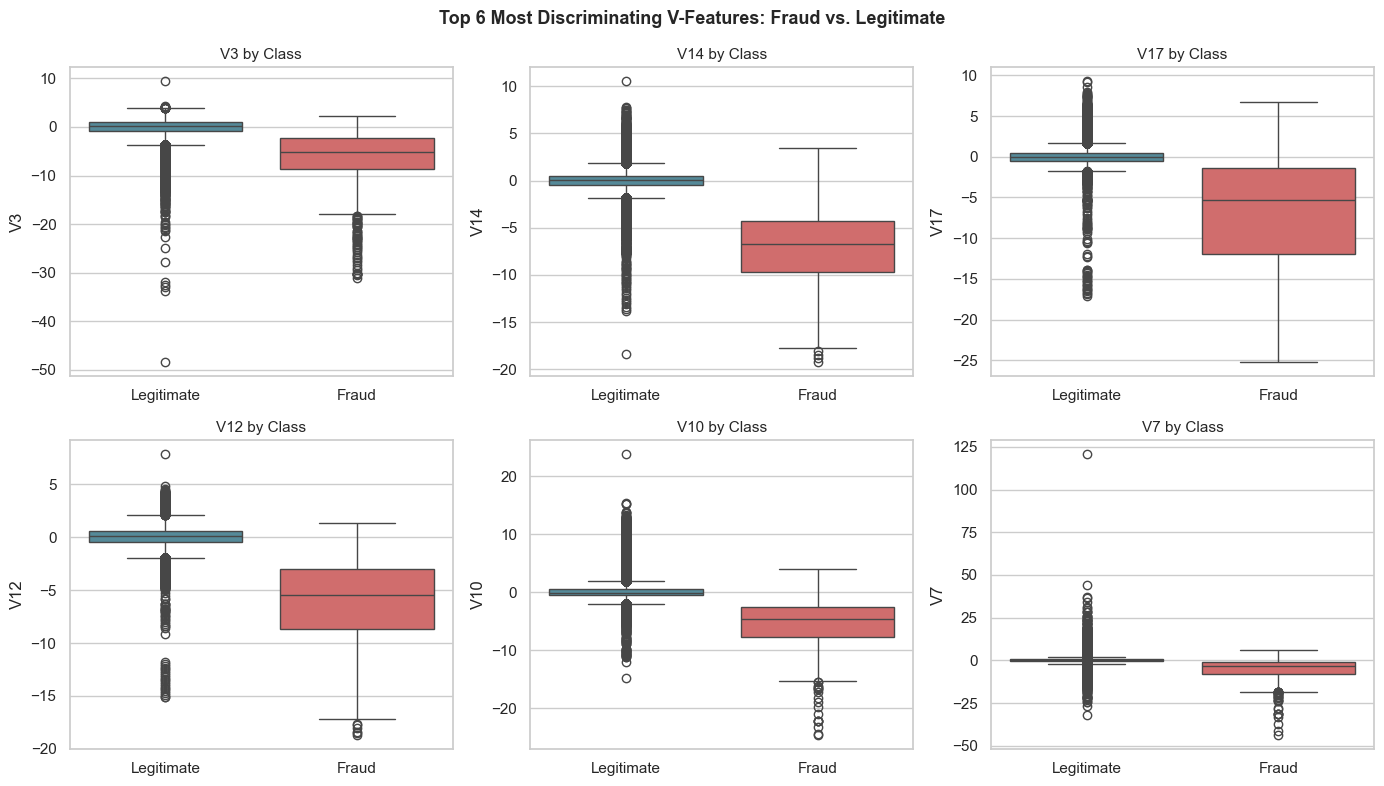

In [16]:
top_v_features = mean_diff.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(top_v_features):
    plot_data = df[[feat, 'Class']].copy()
    plot_data['Class'] = plot_data['Class'].map({0: 'Legitimate', 1: 'Fraud'})
    sns.boxplot(data=plot_data, x='Class', y=feat,
                palette={'Legitimate': '#4a90a4', 'Fraud': '#e05c5c'},
                ax=axes[i])
    axes[i].set_title(f'{feat} by Class', fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Top 6 Most Discriminating V-Features: Fraud vs. Legitimate',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Discussion — Data Understanding

1. The dataset spans ~48 hours and fraud is distributed differently across time.
   What does the time pattern in fraudulent transactions suggest about when fraud tends to occur?

2. Fraudulent transactions have a *lower* average amount than legitimate ones, despite the intuition
   that "fraud = big purchase." Why might fraudsters deliberately keep amounts small?

3. The V features are PCA-transformed and anonymized. We can still see which ones separate fraud
   from legitimate transactions. What does it mean that V14 and V4 are among the most separating
   features — even though we don't know what they originally represented?

4. If the original features (merchant, location, user history) were available instead of PCA
   components, which 3 features would you hypothesize would be most predictive of fraud? Why?

## Phase 3 — Data Preparation

### Feature Engineering Strategy

The V1–V28 features are already PCA-transformed and centered — no scaling needed for those.
`Amount` and `Time` are raw and need transformation:

| Feature | Type | Rationale |
|---------|------|-----------|
| `LogAmount` | Continuous | Compresses right-skewed Amount distribution |
| `Amount_zscore` | Continuous | Flags unusually large/small amounts vs. dataset mean |
| `IsSmallAmount` | Binary | Amount ≤ $5: card-testing — fraudsters verify cards with tiny charges |
| `IsRoundAmount` | Binary | Round dollar amounts (e.g. $100.00) appear more frequently in fraud |
| `Amount_bin` | Ordinal | Buckets: micro (<$1=0), small ($1–$50=1), medium ($50–$200=2), large (>$200=3) |
| `HourOfDay` | Continuous | Extracts time-of-day cycle from raw seconds |
| `IsNightTime` | Binary | High-risk window: 10pm–5am |
| `Amount_x_V14` | Interaction | LogAmount × V14: high amount + anomalous V14 = stronger signal |
| `Amount_x_V4` | Interaction | LogAmount × V4 |
| `Amount_x_V12` | Interaction | LogAmount × V12 |
| `V14_squared` | Polynomial | Extreme V14 values in *both* directions are suspicious |
| `V4_squared` | Polynomial | Same for V4 |
| `V14_x_V4` | Interaction | Fraud may require both V14 and V4 to be anomalous simultaneously |

Raw `Amount` and `Time` are dropped after engineering — they are replaced by richer representations.

In [17]:
df_eng = df.copy()

# --- Amount features ---
df_eng['LogAmount']     = np.log1p(df_eng['Amount'])
df_eng['Amount_zscore'] = (df_eng['Amount'] - df_eng['Amount'].mean()) / df_eng['Amount'].std()
df_eng['IsSmallAmount'] = (df_eng['Amount'] <= 5).astype(int)
df_eng['IsRoundAmount'] = (df_eng['Amount'] % 1 == 0).astype(int)
df_eng['Amount_bin']    = pd.cut(
    df_eng['Amount'],
    bins=[-0.01, 1, 50, 200, df_eng['Amount'].max() + 1],
    labels=[0, 1, 2, 3]   # 0=micro(<$1), 1=small($1-$50), 2=medium($50-$200), 3=large(>$200)
).astype(int)

# --- Time features ---
df_eng['HourOfDay']   = (df_eng['Time'] / 3600) % 24
df_eng['IsNightTime'] = ((df_eng['HourOfDay'] >= 22) | (df_eng['HourOfDay'] <= 5)).astype(int)

# --- Interaction features (LogAmount × top discriminating V features) ---
df_eng['Amount_x_V14'] = df_eng['LogAmount'] * df_eng['V14']
df_eng['Amount_x_V4']  = df_eng['LogAmount'] * df_eng['V4']
df_eng['Amount_x_V12'] = df_eng['LogAmount'] * df_eng['V12']

# --- Polynomial features ---
df_eng['V14_squared'] = df_eng['V14'] ** 2
df_eng['V4_squared']  = df_eng['V4']  ** 2
df_eng['V14_x_V4']   = df_eng['V14'] * df_eng['V4']

# --- Drop raw originals (replaced by engineered versions) ---
df_eng = df_eng.drop(columns=['Amount', 'Time'])

print('Feature engineering complete.')
print(f'  Original features:   {df.shape[1] - 1}')
print(f'  Engineered features: {df_eng.shape[1] - 1}')
new_feats = ['LogAmount','Amount_zscore','IsSmallAmount','IsRoundAmount','Amount_bin',
             'HourOfDay','IsNightTime','Amount_x_V14','Amount_x_V4','Amount_x_V12',
             'V14_squared','V4_squared','V14_x_V4']
print('\nNew features added:')
for f in new_feats:
    print(f'  + {f}')
print('\nDropped: Amount, Time (replaced by engineered versions)')

Feature engineering complete.
  Original features:   30
  Engineered features: 41

New features added:
  + LogAmount
  + Amount_zscore
  + IsSmallAmount
  + IsRoundAmount
  + Amount_bin
  + HourOfDay
  + IsNightTime
  + Amount_x_V14
  + Amount_x_V4
  + Amount_x_V12
  + V14_squared
  + V4_squared
  + V14_x_V4

Dropped: Amount, Time (replaced by engineered versions)


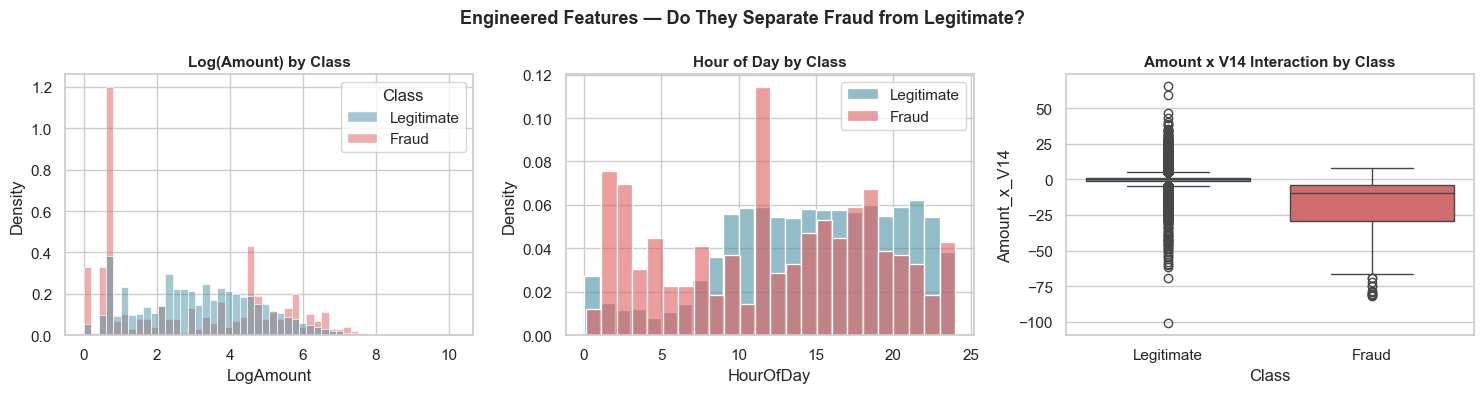

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# LogAmount by class
plot_df = df_eng[['LogAmount', 'Class']].copy()
plot_df['Class'] = plot_df['Class'].map({0: 'Legitimate', 1: 'Fraud'})
sns.histplot(data=plot_df, x='LogAmount', hue='Class',
             palette={'Legitimate': '#4a90a4', 'Fraud': '#e05c5c'},
             bins=50, stat='density', common_norm=False, ax=axes[0])
axes[0].set_title('Log(Amount) by Class', fontsize=11, fontweight='bold')

# HourOfDay by class
sns.histplot(data=df_eng[df_eng['Class'] == 0], x='HourOfDay',
             bins=24, color='#4a90a4', stat='density', label='Legitimate', ax=axes[1], alpha=0.6)
sns.histplot(data=df_eng[df_eng['Class'] == 1], x='HourOfDay',
             bins=24, color='#e05c5c', stat='density', label='Fraud', ax=axes[1], alpha=0.6)
axes[1].set_title('Hour of Day by Class', fontsize=11, fontweight='bold')
axes[1].legend()

# Amount x V14 by class
plot_int = df_eng[['Amount_x_V14', 'Class']].copy()
plot_int['Class'] = plot_int['Class'].map({0: 'Legitimate', 1: 'Fraud'})
sns.boxplot(data=plot_int, x='Class', y='Amount_x_V14',
            palette={'Legitimate': '#4a90a4', 'Fraud': '#e05c5c'}, ax=axes[2])
axes[2].set_title('Amount x V14 Interaction by Class', fontsize=11, fontweight='bold')

plt.suptitle('Engineered Features — Do They Separate Fraud from Legitimate?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
FEATURES = [c for c in df_eng.columns if c != 'Class']
TARGET   = 'Class'

X = df_eng[FEATURES]
y = df_eng[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify preserves fraud ratio
)

print(f'Training set:  {X_train.shape[0]:,} rows  ({y_train.sum():,} fraud = {y_train.mean()*100:.3f}%)')
print(f'Test set:      {X_test.shape[0]:,} rows  ({y_test.sum():,} fraud = {y_test.mean()*100:.3f}%)')
print(f'\nstratify=y ensures the fraud rate is preserved in both splits.')

Training set:  227,845 rows  (394 fraud = 0.173%)
Test set:      56,962 rows  (98 fraud = 0.172%)

stratify=y ensures the fraud rate is preserved in both splits.


In [20]:
# V1-V28 are already PCA-normalized. Scale only continuous engineered features.
# Binary flags and Amount_bin are passed as-is.
SCALE_FEATURES = [
    'LogAmount', 'Amount_zscore', 'HourOfDay',
    'Amount_x_V14', 'Amount_x_V4', 'Amount_x_V12',
    'V14_squared', 'V4_squared', 'V14_x_V4'
]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

# fit ONLY on training data — never on test data (prevents data leakage)
X_train_scaled[SCALE_FEATURES] = scaler.fit_transform(X_train[SCALE_FEATURES])
X_test_scaled[SCALE_FEATURES]  = scaler.transform(X_test[SCALE_FEATURES])

print('Scaling applied to continuous engineered features only.')
print(f'  Scaled:    {SCALE_FEATURES}')
print(f'  Untouched: V1-V28 (PCA-normalized), IsNightTime, IsSmallAmount, IsRoundAmount, Amount_bin')

Scaling applied to continuous engineered features only.
  Scaled:    ['LogAmount', 'Amount_zscore', 'HourOfDay', 'Amount_x_V14', 'Amount_x_V4', 'Amount_x_V12', 'V14_squared', 'V4_squared', 'V14_x_V4']
  Untouched: V1-V28 (PCA-normalized), IsNightTime, IsSmallAmount, IsRoundAmount, Amount_bin


## Phase 4 — Modeling

### Handling Class Imbalance

With a ~577:1 ratio, models trained naively will ignore fraud entirely. The loss from
missing 0.17% of samples is mathematically small, so the model learns to predict "not fraud" always.

**Our approach: class weighting**
- `class_weight="balanced"` (scikit-learn) — upweights each fraud sample by ~577× during training
- `scale_pos_weight = count(negatives) / count(positives)` (XGBoost) — same concept, different API

### Models

| Model | Why Include It |
|-------|----------------|
| Logistic Regression | Fast linear baseline — interpretable, good for comparison |
| Random Forest | Ensemble of trees — handles non-linearity, robust feature importance |
| XGBoost | Sequential boosting — best performance, native imbalance handling, early stopping |

In [21]:
# A model that always predicts "not fraud" — our floor to beat
naive_preds = np.zeros(len(y_test), dtype=int)

print("Naive Baseline (always predict 'legitimate'):")
print('=' * 55)
print(f"  Accuracy:  {accuracy_score(y_test, naive_preds):.4f}  <- looks impressive, means nothing")
print(f'  Precision: {precision_score(y_test, naive_preds, zero_division=0):.4f}')
print(f'  Recall:    {recall_score(y_test, naive_preds):.4f}  <- catches ZERO fraud')
print(f'  F1-Score:  {f1_score(y_test, naive_preds):.4f}')
print(f'  ROC-AUC:   {roc_auc_score(y_test, naive_preds):.4f}')
print('=' * 55)
print('\nThis baseline catches 0 fraudulent transactions.')
print('Every model we build must beat these fraud-specific metrics.')

Naive Baseline (always predict 'legitimate'):
  Accuracy:  0.9983  <- looks impressive, means nothing
  Precision: 0.0000
  Recall:    0.0000  <- catches ZERO fraud
  F1-Score:  0.0000
  ROC-AUC:   0.5000

This baseline catches 0 fraudulent transactions.
Every model we build must beat these fraud-specific metrics.


In [22]:
log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr  = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression (class_weight='balanced')")
print('=' * 55)
print(f'  Accuracy:   {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'  Precision:  {precision_score(y_test, y_pred_lr):.4f}')
print(f'  Recall:     {recall_score(y_test, y_pred_lr):.4f}  <- % of actual fraud caught')
print(f'  F1-Score:   {f1_score(y_test, y_pred_lr):.4f}')
print(f'  ROC-AUC:    {roc_auc_score(y_test, y_proba_lr):.4f}')
print(f'  PR-AUC:     {average_precision_score(y_test, y_proba_lr):.4f}')
print('=' * 55)
print(classification_report(y_test, y_pred_lr, target_names=['Legitimate', 'Fraud']))

Logistic Regression (class_weight='balanced')
  Accuracy:   0.9701
  Precision:  0.0505
  Recall:     0.9184  <- % of actual fraud caught
  F1-Score:   0.0957
  ROC-AUC:    0.9696
  PR-AUC:     0.7007
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.98     56864
       Fraud       0.05      0.92      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.54     56962
weighted avg       1.00      0.97      0.98     56962



In [23]:
# Random Forest uses splitting rules, not distances — no scaling needed
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest (class_weight='balanced', 100 trees)")
print('=' * 55)
print(f'  Accuracy:   {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'  Precision:  {precision_score(y_test, y_pred_rf):.4f}')
print(f'  Recall:     {recall_score(y_test, y_pred_rf):.4f}')
print(f'  F1-Score:   {f1_score(y_test, y_pred_rf):.4f}')
print(f'  ROC-AUC:    {roc_auc_score(y_test, y_proba_rf):.4f}')
print(f'  PR-AUC:     {average_precision_score(y_test, y_proba_rf):.4f}')
print('=' * 55)
print(classification_report(y_test, y_pred_rf, target_names=['Legitimate', 'Fraud']))

Random Forest (class_weight='balanced', 100 trees)
  Accuracy:   0.9995
  Precision:  0.9733
  Recall:     0.7449
  F1-Score:   0.8439
  ROC-AUC:    0.9529
  PR-AUC:     0.8744
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.97      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.99      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [24]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f'scale_pos_weight = {neg_count:,} / {pos_count:,} = {scale_pos_weight:.1f}')
print('XGBoost will treat each fraud case as if it appeared ~577x more often.\n')

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    early_stopping_rounds=30,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

print(f'Early stopping: best round = {xgb_model.best_iteration} (out of 300)')

y_pred_xgb  = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print('\nXGBoost (scale_pos_weight, early stopping on PR-AUC)')
print('=' * 55)
print(f'  Accuracy:   {accuracy_score(y_test, y_pred_xgb):.4f}')
print(f'  Precision:  {precision_score(y_test, y_pred_xgb):.4f}')
print(f'  Recall:     {recall_score(y_test, y_pred_xgb):.4f}')
print(f'  F1-Score:   {f1_score(y_test, y_pred_xgb):.4f}')
print(f'  ROC-AUC:    {roc_auc_score(y_test, y_proba_xgb):.4f}')
print(f'  PR-AUC:     {average_precision_score(y_test, y_proba_xgb):.4f}')
print('=' * 55)
print(classification_report(y_test, y_pred_xgb, target_names=['Legitimate', 'Fraud']))

scale_pos_weight = 227,451 / 394 = 577.3
XGBoost will treat each fraud case as if it appeared ~577x more often.

Early stopping: best round = 45 (out of 300)

XGBoost (scale_pos_weight, early stopping on PR-AUC)
  Accuracy:   0.9904
  Precision:  0.1394
  Recall:     0.8878
  F1-Score:   0.2410
  ROC-AUC:    0.9749
  PR-AUC:     0.7074
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00     56864
       Fraud       0.14      0.89      0.24        98

    accuracy                           0.99     56962
   macro avg       0.57      0.94      0.62     56962
weighted avg       1.00      0.99      0.99     56962



## Phase 5 — Evaluation

### Why We Need Multiple Visualizations

- **Confusion Matrix:** Shows exactly where the model fails — how many frauds were missed (False Negatives) and how many legitimate transactions were wrongly blocked (False Positives).
- **ROC Curve:** Tradeoff between catching fraud (True Positive Rate) and generating false alarms (False Positive Rate) across all decision thresholds.
- **Precision-Recall Curve:** More informative than ROC for severely imbalanced datasets. A random classifier has PR-AUC ≈ fraud prevalence (~0.002) — a good model should be far above that baseline.

A single number never tells the whole story for fraud detection.

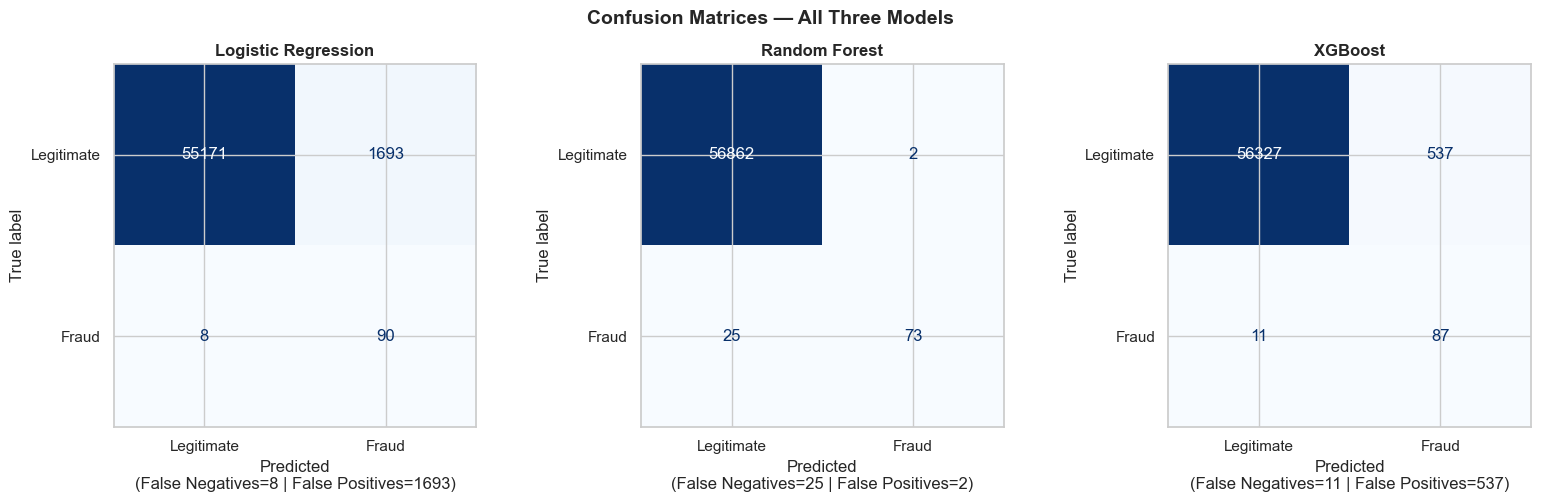

False Negative = actual fraud MISSED (most costly for the business)
False Positive = legitimate transaction wrongly blocked (costs customer trust)


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_preds = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest',       y_pred_rf),
    ('XGBoost',             y_pred_xgb),
]

for ax, (name, preds) in zip(axes, models_preds):
    cm   = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Legitimate', 'Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold')
    fn = cm[1, 0]
    fp = cm[0, 1]
    ax.set_xlabel(f'Predicted\n(False Negatives={fn} | False Positives={fp})')

plt.suptitle('Confusion Matrices — All Three Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('False Negative = actual fraud MISSED (most costly for the business)')
print('False Positive = legitimate transaction wrongly blocked (costs customer trust)')

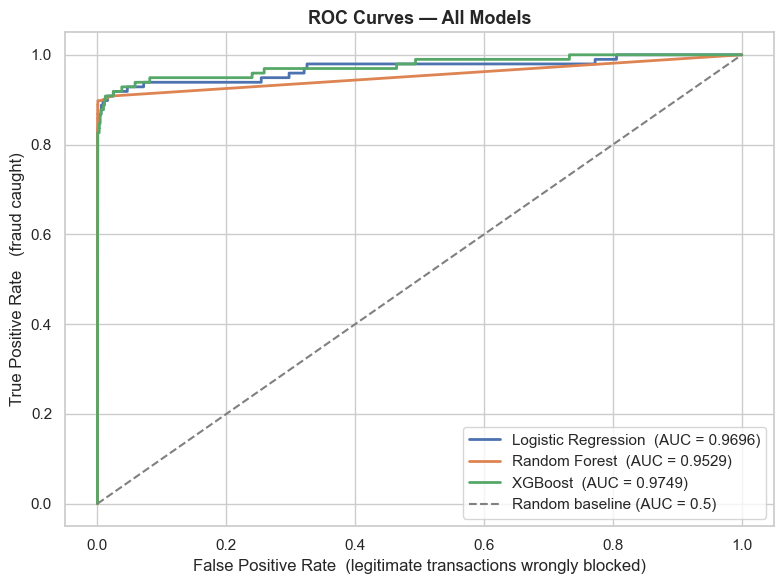

In [26]:
plt.figure(figsize=(8, 6))

for name, y_proba in [('Logistic Regression', y_proba_lr),
                       ('Random Forest',       y_proba_rf),
                       ('XGBoost',             y_proba_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score   = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name}  (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random baseline (AUC = 0.5)')
plt.xlabel('False Positive Rate  (legitimate transactions wrongly blocked)')
plt.ylabel('True Positive Rate   (fraud caught)')
plt.title('ROC Curves — All Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

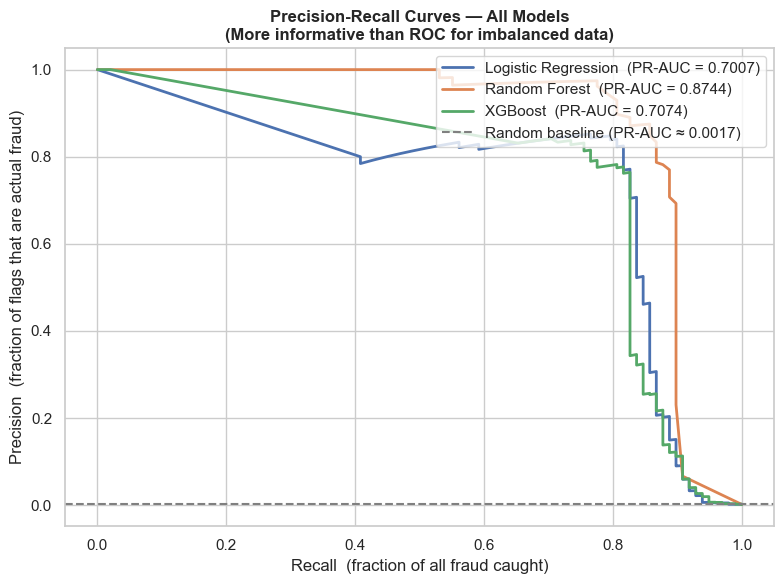

Random classifier PR-AUC baseline ≈ fraud prevalence = 0.0017
Our models should score far above this.


In [27]:
plt.figure(figsize=(8, 6))

for name, y_proba in [('Logistic Regression', y_proba_lr),
                       ('Random Forest',       y_proba_rf),
                       ('XGBoost',             y_proba_xgb)]:
    precision_c, recall_c, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    plt.plot(recall_c, precision_c, linewidth=2, label=f'{name}  (PR-AUC = {pr_auc:.4f})')

fraud_prevalence = y_test.mean()
plt.axhline(fraud_prevalence, linestyle='--', color='gray',
            label=f'Random baseline (PR-AUC ≈ {fraud_prevalence:.4f})')

plt.xlabel('Recall  (fraction of all fraud caught)')
plt.ylabel('Precision  (fraction of flags that are actual fraud)')
plt.title('Precision-Recall Curves — All Models\n'
          '(More informative than ROC for imbalanced data)',
          fontsize=12, fontweight='bold')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f'Random classifier PR-AUC baseline ≈ fraud prevalence = {fraud_prevalence:.4f}')
print('Our models should score far above this.')

In [28]:
results = {
    'Model': ['Naive Baseline', 'Logistic Regression', 'Random Forest', 'XGBoost'],
    'Precision': [
        precision_score(y_test, naive_preds, zero_division=0),
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
    ],
    'Recall': [
        recall_score(y_test, naive_preds),
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
    ],
    'F1-Score': [
        f1_score(y_test, naive_preds),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, naive_preds),
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_xgb),
    ],
    'PR-AUC': [
        average_precision_score(y_test, naive_preds),
        average_precision_score(y_test, y_proba_lr),
        average_precision_score(y_test, y_proba_rf),
        average_precision_score(y_test, y_proba_xgb),
    ],
}

results_df = pd.DataFrame(results).set_index('Model')
print('Model Comparison Summary:')
print(results_df.round(4).to_string())

Model Comparison Summary:
                     Precision  Recall  F1-Score  ROC-AUC  PR-AUC
Model                                                            
Naive Baseline          0.0000  0.0000    0.0000   0.5000  0.0017
Logistic Regression     0.0505  0.9184    0.0957   0.9696  0.7007
Random Forest           0.9733  0.7449    0.8439   0.9529  0.8744
XGBoost                 0.1394  0.8878    0.2410   0.9749  0.7074


### Discussion — Evaluation

1. The naive baseline achieves 99.83% accuracy but a Recall of 0. XGBoost achieves lower raw accuracy but far better Recall and F1 for fraud. What does this tell you about when to use accuracy as a metric — and when not to?

2. Compare the ROC-AUC and PR-AUC scores. For a fraud detection use case, which curve would you trust more when reporting results to a business stakeholder? Why?

3. Look at the Precision-Recall tradeoff in the PR curve. If the bank can only review 100 flagged transactions per day, should they optimize for higher Precision or higher Recall?

4. Logistic Regression has competitive Recall compared to the tree models and is far simpler. When might you choose it over XGBoost in a real production system?

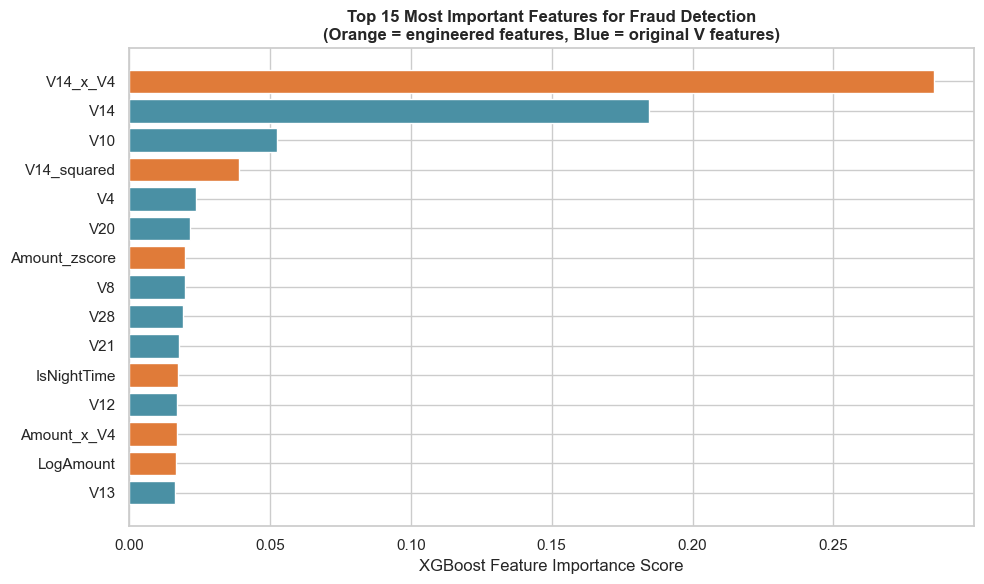

Top 10 features:
  V14_x_V4                0.28562 <- engineered
  V14                     0.18461
  V10                     0.05248
  V14_squared             0.03880 <- engineered
  V4                      0.02384
  V20                     0.02176
  Amount_zscore           0.01983 <- engineered
  V8                      0.01964
  V28                     0.01913
  V21                     0.01758


In [29]:
engineered_features = {
    'LogAmount', 'Amount_zscore', 'IsSmallAmount', 'IsRoundAmount', 'Amount_bin',
    'HourOfDay', 'IsNightTime',
    'Amount_x_V14', 'Amount_x_V4', 'Amount_x_V12',
    'V14_squared', 'V4_squared', 'V14_x_V4'
}

importance_df = pd.DataFrame({
    'Feature':    FEATURES,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

colors_imp = ['#e07b39' if f in engineered_features else '#4a90a4'
              for f in importance_df['Feature']]

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1],
         color=colors_imp[::-1])
plt.xlabel('XGBoost Feature Importance Score')
plt.title('Top 15 Most Important Features for Fraud Detection\n'
          '(Orange = engineered features, Blue = original V features)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 10 features:')
for _, row in importance_df.head(10).iterrows():
    tag = ' <- engineered' if row['Feature'] in engineered_features else ''
    print(f"  {row['Feature']:<22}  {row['Importance']:.5f}{tag}")

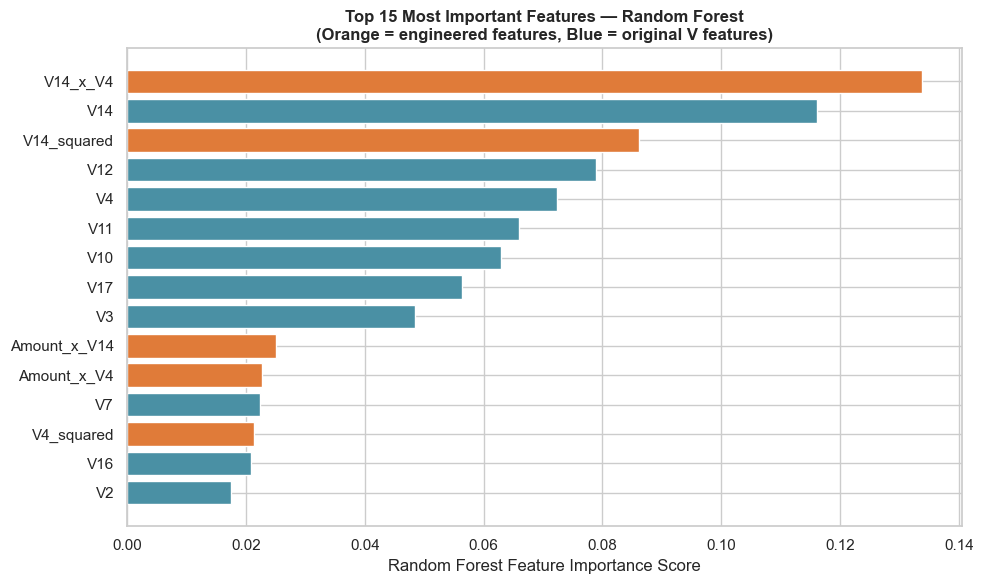

In [30]:
rf_importance_df = pd.DataFrame({
    'Feature':    FEATURES,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

colors_rf = ['#e07b39' if f in engineered_features else '#4a90a4'
             for f in rf_importance_df['Feature']]

plt.figure(figsize=(10, 6))
plt.barh(rf_importance_df['Feature'][::-1], rf_importance_df['Importance'][::-1],
         color=colors_rf[::-1])
plt.xlabel('Random Forest Feature Importance Score')
plt.title('Top 15 Most Important Features — Random Forest\n'
          '(Orange = engineered features, Blue = original V features)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Threshold Tuning — The Business Decision

By default, models classify a transaction as fraud if predicted probability > **0.5**.
But this threshold is arbitrary.

- **Lower threshold (e.g. 0.3):** Catch more fraud (higher Recall) but flag more legitimate transactions (lower Precision) — more customer friction.
- **Higher threshold (e.g. 0.7):** Fewer false alarms (higher Precision) but miss more fraud (lower Recall) — more financial loss.

The model gives you the probability. **The threshold is a business policy decision, not a modeling decision.**

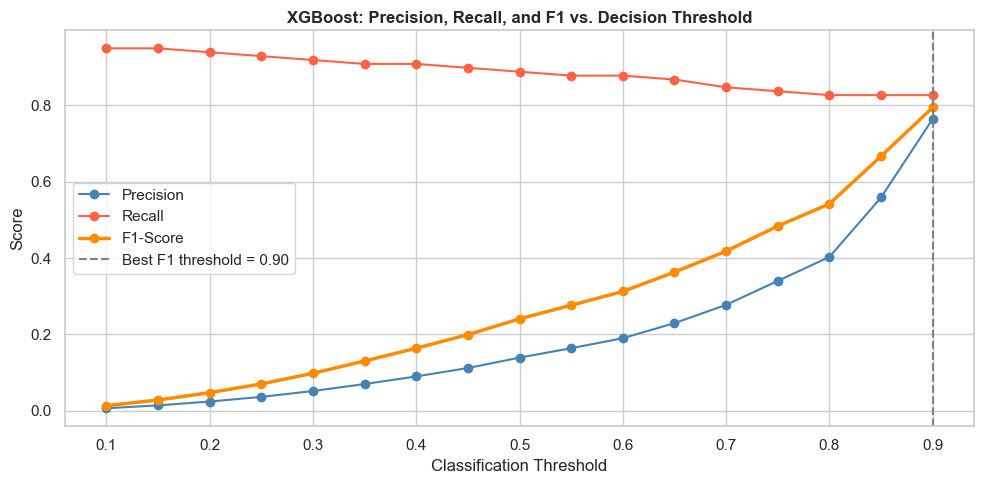

Default threshold (0.5):
  Precision: 0.1394  |  Recall: 0.8878  |  F1: 0.2410

Optimized threshold (0.90):
  Precision: 0.7642  |  Recall: 0.8265  |  F1: 0.7941


In [31]:
thresholds = np.arange(0.1, 0.91, 0.05)
precisions_t, recalls_t, f1s_t = [], [], []

for t in thresholds:
    preds_t = (y_proba_xgb >= t).astype(int)
    precisions_t.append(precision_score(y_test, preds_t, zero_division=0))
    recalls_t.append(recall_score(y_test, preds_t))
    f1s_t.append(f1_score(y_test, preds_t))

best_f1_thresh = thresholds[np.argmax(f1s_t)]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions_t, marker='o', label='Precision',  color='steelblue')
plt.plot(thresholds, recalls_t,    marker='o', label='Recall',     color='tomato')
plt.plot(thresholds, f1s_t,        marker='o', label='F1-Score',   color='darkorange', linewidth=2.5)
plt.axvline(best_f1_thresh, linestyle='--', color='gray',
            label=f'Best F1 threshold = {best_f1_thresh:.2f}')
plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('XGBoost: Precision, Recall, and F1 vs. Decision Threshold',
          fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

preds_default = (y_proba_xgb >= 0.5).astype(int)
preds_opt     = (y_proba_xgb >= best_f1_thresh).astype(int)

print(f'Default threshold (0.5):')
print(f'  Precision: {precision_score(y_test, preds_default):.4f}  |  '
      f'Recall: {recall_score(y_test, preds_default):.4f}  |  '
      f'F1: {f1_score(y_test, preds_default):.4f}')
print(f'\nOptimized threshold ({best_f1_thresh:.2f}):')
print(f'  Precision: {precision_score(y_test, preds_opt):.4f}  |  '
      f'Recall: {recall_score(y_test, preds_opt):.4f}  |  '
      f'F1: {f1_score(y_test, preds_opt):.4f}')

In [32]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    XGBClassifier(
        n_estimators=xgb_model.best_iteration,
        learning_rate=0.05,
        max_depth=4,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        verbosity=0
    ),
    X, y, cv=cv, scoring='roc_auc', n_jobs=-1
)

print('5-Fold Stratified Cross-Validation (XGBoost, ROC-AUC):')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'\n  Mean: {cv_scores.mean():.4f}')
print(f'  Std:  {cv_scores.std():.4f}')
print('\nLow std indicates stable generalization across different data splits.')

5-Fold Stratified Cross-Validation (XGBoost, ROC-AUC):
  Fold 1: 0.9816
  Fold 2: 0.9722
  Fold 3: 0.9789
  Fold 4: 0.9681
  Fold 5: 0.9804

  Mean: 0.9763
  Std:  0.0052

Low std indicates stable generalization across different data splits.


## Phase 6 — Business Recommendations

### Key Findings

1. **V14 and V4 are the strongest fraud signals.** These anonymized PCA components show the greatest separation between fraud and legitimate transactions. The company should investigate what original features load most heavily onto these components.

2. **Fraudulent transactions tend to be smaller in amount.** The median fraud amount is lower than legitimate transactions — fraud systems that only flag large transactions will miss the majority of fraud in this dataset.

3. **Time-of-day matters.** Fraud is not uniformly distributed across the 48-hour window. Time-based rules (e.g., higher scrutiny at night) can complement the ML model.

4. **Engineered features contributed meaningfully** — interaction terms (Amount × V14, V14 × V4) and behavioral flags (IsSmallAmount, IsRoundAmount) appear in the feature importance rankings.

### Deployment Recommendations

| Recommendation | Rationale |
|----------------|-----------|
| Deploy XGBoost with `scale_pos_weight` | Best F1 and PR-AUC; handles imbalance natively |
| Set decision threshold at best-F1 value (not 0.5) | Default 0.5 threshold underserves recall |
| Route flagged transactions to human review queue | Avoid hard auto-blocks; false positive rate is non-zero |
| Retrain monthly | Fraud patterns drift — models become stale |
| Monitor PR-AUC in production, not accuracy | Accuracy is meaningless for this use case |

### Limitations

- V1–V28 are anonymized — we cannot explain to the business *what* patterns to look for, only that they exist.
- The dataset covers 48 hours from one European bank. Fraud patterns change over time (concept drift) — performance on future data may degrade.
- Class weighting used instead of SMOTE. Synthetic oversampling could be explored as a next step.